<a href="https://colab.research.google.com/github/Arshavardhini321/Decision_Tree-Bank_loan_Analyzer-/blob/main/Decision_Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Decision Tree**

**Load Dataset**

In [47]:
import pandas as pd

url = "https://raw.githubusercontent.com/Arshavardhini321/Decision_Tree-Bank_loan_Analyzer-/refs/heads/main/loan_approval_dataset_500.csv"


data = pd.read_csv(url)

**Import Libraries**

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Understand the Dataset:head(),info(),describe()**

In [49]:
data.head()

,Age,Annual_Income,Credit_Score,Loan_Amount,Existing_Loan,Employment_Years,Loan_Status
0,41,49772,752,391277,Yes,2,Rejected
1,27,77931,848,80408,Yes,1,Rejected
2,47,39156,673,97559,No,1,Rejected
3,28,59260,848,82433,No,1,Rejected
4,23,102963,618,201838,No,4,Rejected


In [50]:
print(data['Existing_Loan'].unique())
print(data['Loan_Status'].unique())

['Yes' 'No']
['Rejected' 'Approved']


In [51]:
data['Existing_Loan'] = data['Existing_Loan'].replace({
    'Yes': 1,
    'No': 0
})

data['Loan_Status'] = data['Loan_Status'].replace({
    'Approved': 1,
    'Rejected': 0
})

/tmp/ipykernel_16037/538164491.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['Existing_Loan'] = data['Existing_Loan'].replace({
/tmp/ipykernel_16037/538164491.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['Loan_Status'] = data['Loan_Status'].replace({


Dataset Information:Rows,columns


In [52]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Age               500 non-null    int64
 1   Annual_Income     500 non-null    int64
 2   Credit_Score      500 non-null    int64
 3   Loan_Amount       500 non-null    int64
 4   Existing_Loan     500 non-null    int64
 5   Employment_Years  500 non-null    int64
 6   Loan_Status       500 non-null    int64
dtypes: int64(7)
memory usage: 27.5 KB


describe:

To understand the numerical properties of the dataset.
It shows:
Mean
Standard Deviation
Minimum
Maximum
Quartiles

In [53]:
data.describe()

,Age,Annual_Income,Credit_Score,Loan_Amount,Existing_Loan,Employment_Years,Loan_Status
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000
mean,40.996000,86802.076000,703.128000,274235.312000,0.536000,12.402000,0.15200
std,11.507947,33640.956015,85.693865,129229.125194,0.499202,7.756076,0.35938
min,21.000000,30127.000000,550.000000,51977.000000,0.000000,0.000000,0.00000
25%,31.750000,56794.500000,633.000000,166185.500000,0.000000,5.000000,0.00000
50%,41.000000,86975.500000,703.000000,269359.500000,1.000000,12.500000,0.00000
75%,51.000000,114350.000000,776.000000,384590.000000,1.000000,20.000000,0.00000
max,60.000000,149777.000000,850.000000,498508.000000,1.000000,25.000000,1.00000


**visualization**

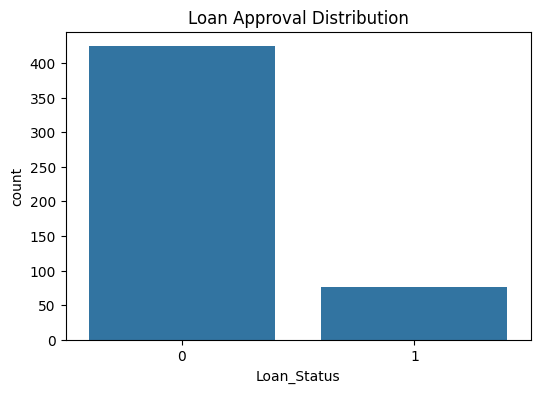

In [54]:
plt.figure(figsize=(6,4))

sns.countplot(x='Loan_Status', data=data)

plt.title("Loan Approval Distribution")

plt.show()

  **Freature_selection**

In [55]:
X = data[['Age',
          'Annual_Income',
          'Credit_Score',
          'Loan_Amount',
          'Existing_Loan',
          'Employment_Years']]

y = data['Loan_Status']

**Train-Test Split**

In [56]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [57]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

**Train the Model**

In [58]:
model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)

print("Decision Tree Model Trained Successfully")


Decision Tree Model Trained Successfully


**Make Predictions**

In [59]:
y_pred = model.predict(X_test)

**Compare Actual vs Predicted**

In [60]:
comparison = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

comparison

,Actual,Predicted
361,0,0
73,0,0
374,1,0
155,0,0
104,0,0
...,...,...
347,0,0
86,0,0
75,0,0
438,1,1


**Accuracy Score**

In [61]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.85


**Confusion Matrix**

In [62]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

cm

array([[74,  9],
       [ 6, 11]])

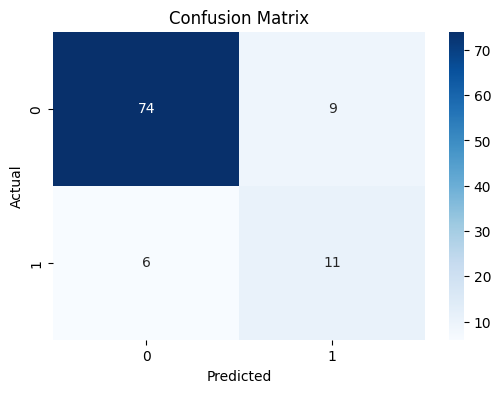

In [63]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

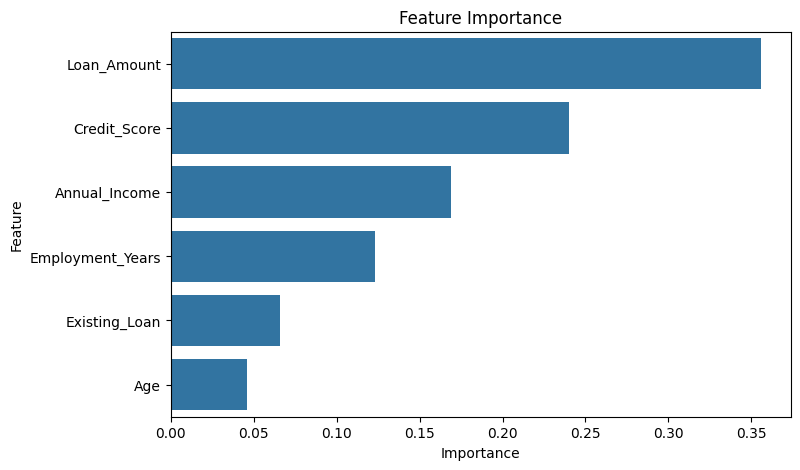

In [64]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8,5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title("Feature Importance")

plt.show()

In [65]:
new_applicant = pd.DataFrame({
    'Age':[30],
    'Annual_Income':[70000],
    'Credit_Score':[740],
    'Loan_Amount':[200000],
    'Existing_Loan':[0],
    'Employment_Years':[8]
})

prediction = model.predict(new_applicant)

if prediction[0] == 1:
    print("Loan Approved")
else:
    print("Loan Rejected")

Loan Rejected


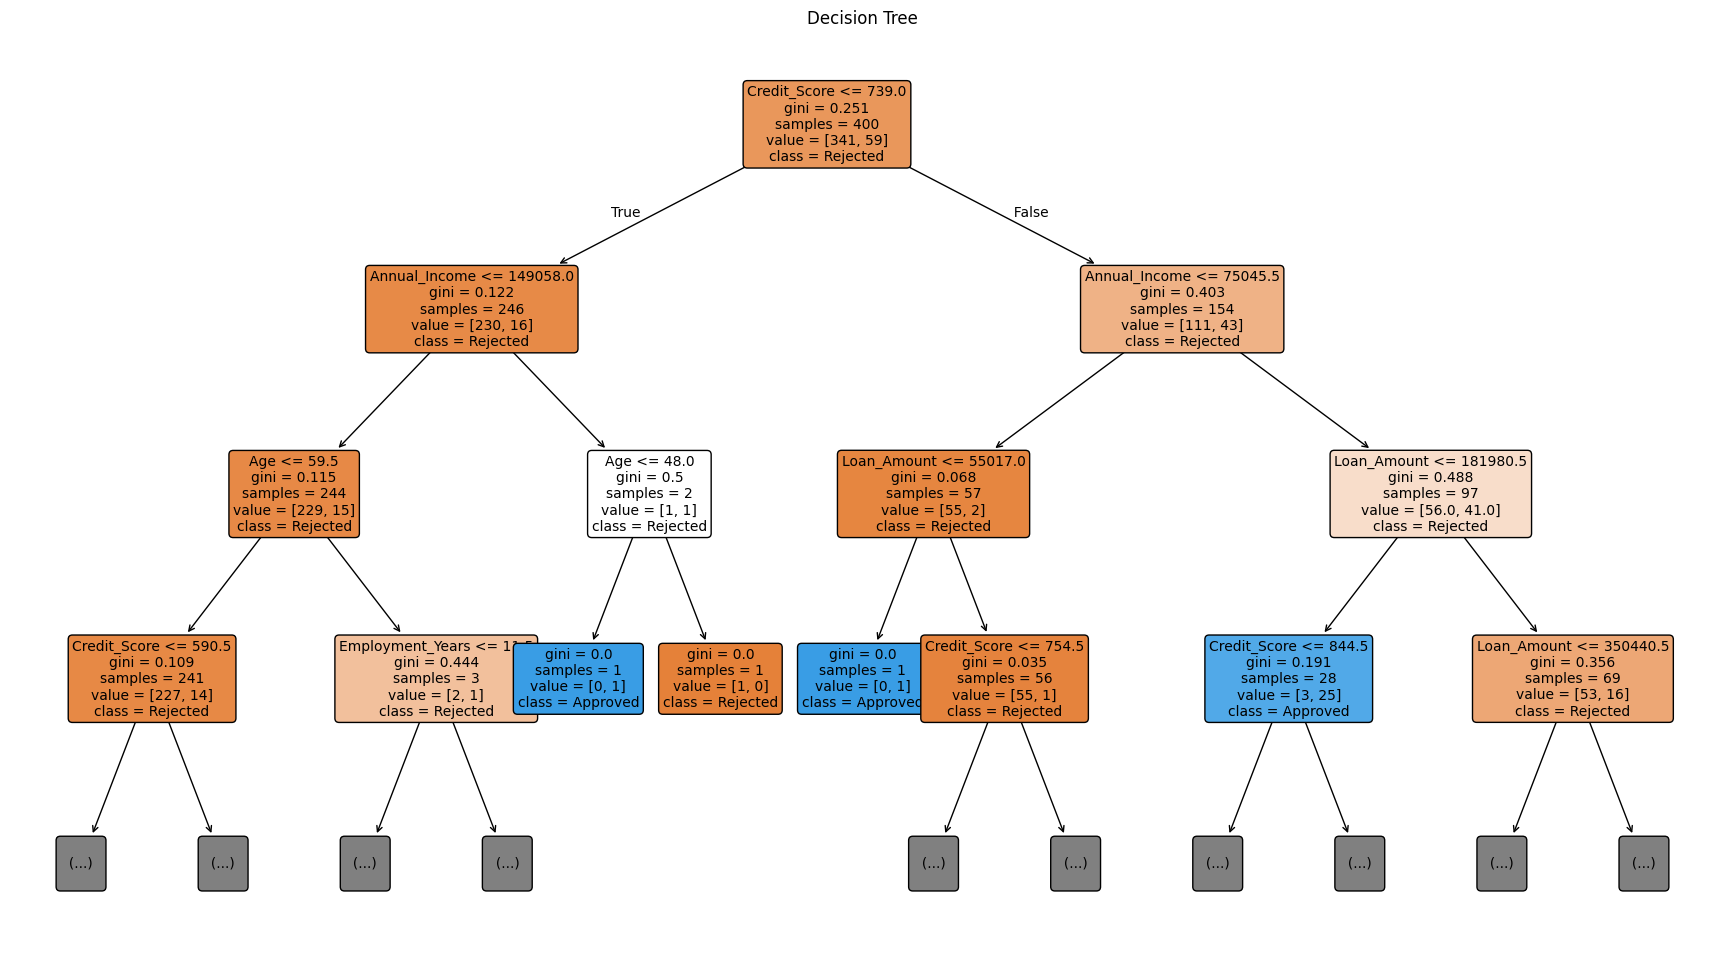

In [69]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(22,12))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Rejected", "Approved"],
    filled=True,
    rounded=True,
    fontsize=10,
    max_depth=3          # Shows only first 4 levels (0,1,2,3)
)

plt.title("Decision Tree")
plt.show()